#CELL 1 Tai du lieu

In [1]:
import kagglehub, os

path = kagglehub.dataset_download("zalando-research/fashionmnist")
print("Path to dataset files:", path)

print("\nCac file trong dataset:")
for root, dirs, fs in os.walk(path):
    for f in fs:
        print(os.path.join(root, f))

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist

Cac file trong dataset:
/kaggle/input/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/fashionmnist/fashion-mnist_test.csv
/kaggle/input/fashionmnist/fashion-mnist_train.csv
/kaggle/input/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/fashionmnist/train-images-idx3-ubyte


# Cell 2: Nap thu vien

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense

# Cell 3: Doc file CSV train va test
# Tu dong tim file csv chua chu 'train' va 'test'

In [3]:
train_csv = glob(path + '/**/*train*.csv', recursive=True)[0]
test_csv  = glob(path + '/**/*test*.csv', recursive=True)[0]
print("File train:", train_csv)
print("File test :", test_csv)

df_train = pd.read_csv(train_csv)
df_test  = pd.read_csv(test_csv)

# Cot dau tien la nhan (label), cac cot con lai la pixel
y_train = df_train.iloc[:, 0].values
X_train = df_train.iloc[:, 1:].values

y_test = df_test.iloc[:, 0].values
X_test = df_test.iloc[:, 1:].values

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("Cac nhan co trong du lieu:", np.unique(y_train))

File train: /kaggle/input/fashionmnist/fashion-mnist_train.csv
File test : /kaggle/input/fashionmnist/fashion-mnist_test.csv
X_train: (60000, 784) | y_train: (60000,)
Cac nhan co trong du lieu: [0 1 2 3 4 5 6 7 8 9]


# Cell 4: Dua pixel ve dang anh (28,28,1), chuan hoa, one-hot nhan
# 784 pixel -> 28 x 28 x 1 (1 vi anh grayscale)

In [5]:
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot nhan (10 lop)
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Anh sau reshape:", X_train.shape)   # (60000, 28, 28, 1)

Anh sau reshape: (60000, 28, 28, 1)


# Cell 5: Xay dung CNN (dung dung kien truc trong tai lieu)

In [6]:
input_shape = (28, 28, 1)

model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))   # 10 lop quan ao
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

# Cell 6: Compile va huan luyen

In [7]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train_oh,
                    validation_data=(X_test, y_test_oh),
                    epochs=10,
                    batch_size=64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 51ms/step - accuracy: 0.6029 - loss: 1.1712 - val_accuracy: 0.7216 - val_loss: 0.7772
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.7335 - loss: 0.7250 - val_accuracy: 0.7470 - val_loss: 0.7030
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.7522 - loss: 0.6742 - val_accuracy: 0.7638 - val_loss: 0.6558
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.7660 - loss: 0.6390 - val_accuracy: 0.7740 - val_loss: 0.6288
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.7772 - loss: 0.6097 - val_accuracy: 0.7847 - val_loss: 0.5910
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 50ms/step - accuracy: 0.7868 - loss: 0.5823 - val_accuracy: 0.7960 - val_loss: 0.5694
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.7953 - loss: 0.5580 - val_accuracy: 0.8003 - val_loss: 0.5447
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.8015 - loss: 0.5384 - 

# Cell 7: Danh gia + ve bieu do

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8179 - loss: 0.4967
Do chinh xac tren tap test: 81.79 %


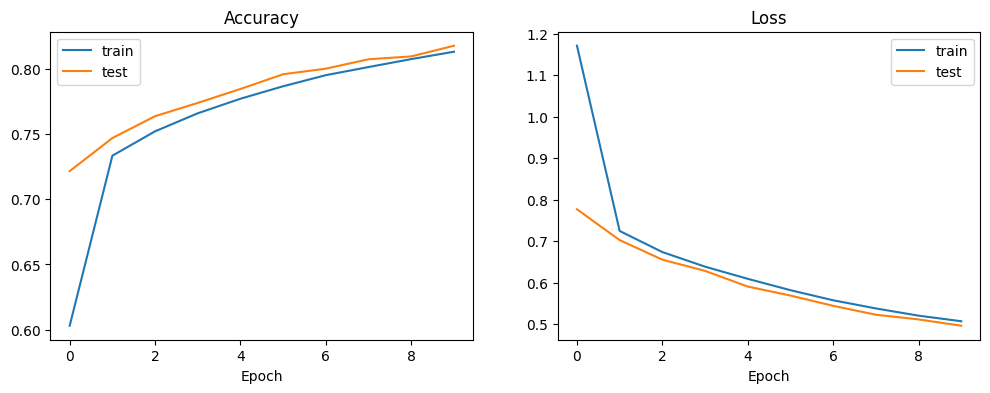

In [8]:
loss, acc = model.evaluate(X_test, y_test_oh)
print("Do chinh xac tren tap test:", round(acc*100, 2), "%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.show()

# Cell 8: Thu du doan 1 anh trong tap test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


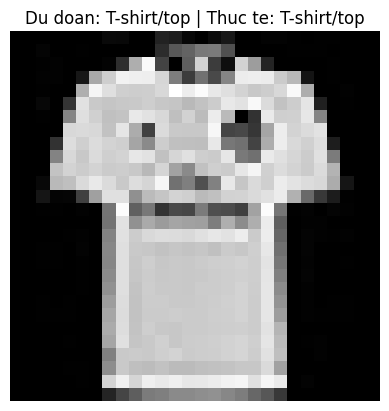

In [9]:
ten_lop = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

idx = 0   # doi so de thu anh khac
anh = X_test[idx]
du_doan = model.predict(anh.reshape(1, 28, 28, 1))
nhan_du_doan = ten_lop[np.argmax(du_doan)]
nhan_that = ten_lop[y_test[idx]]

plt.imshow(anh.reshape(28, 28), cmap='gray')
plt.title("Du doan: " + nhan_du_doan + " | Thuc te: " + nhan_that)
plt.axis('off')
plt.show()